First 5 Rows:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


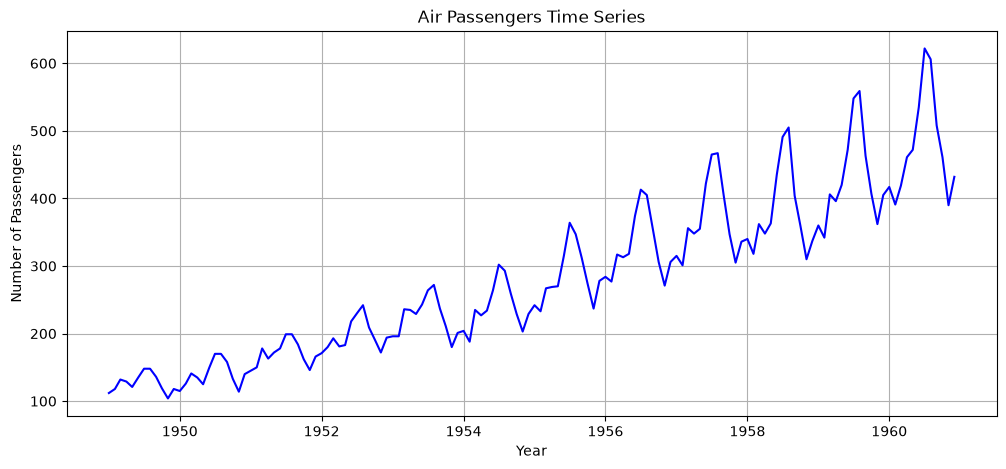

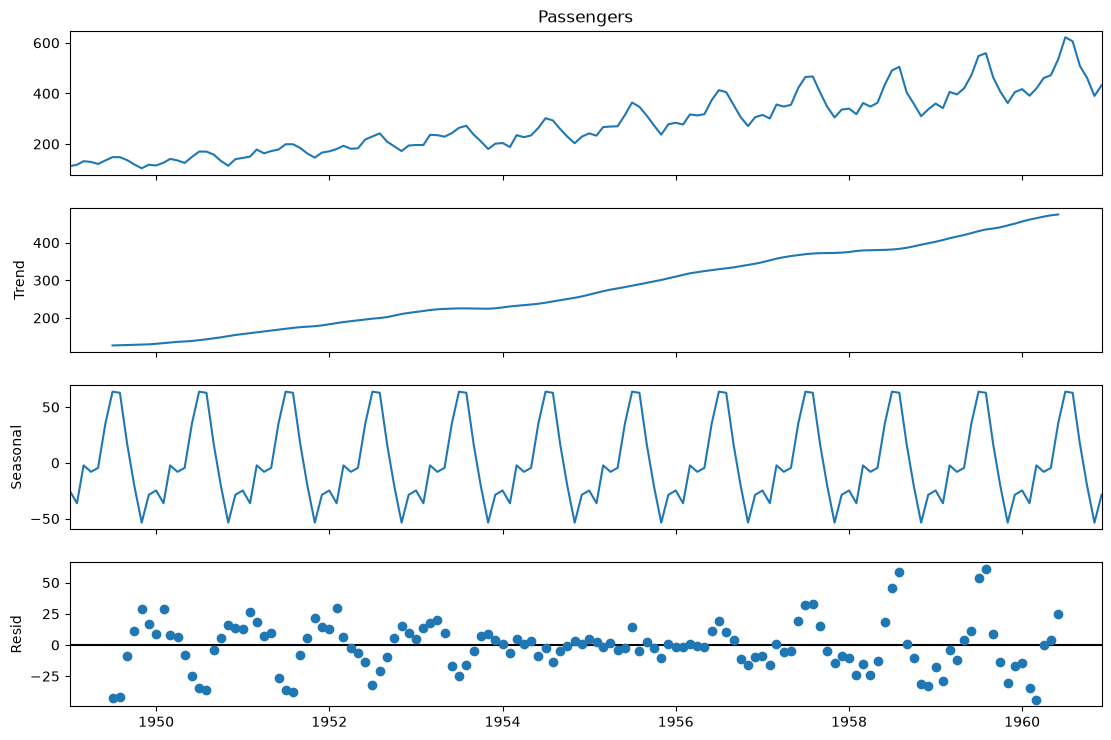

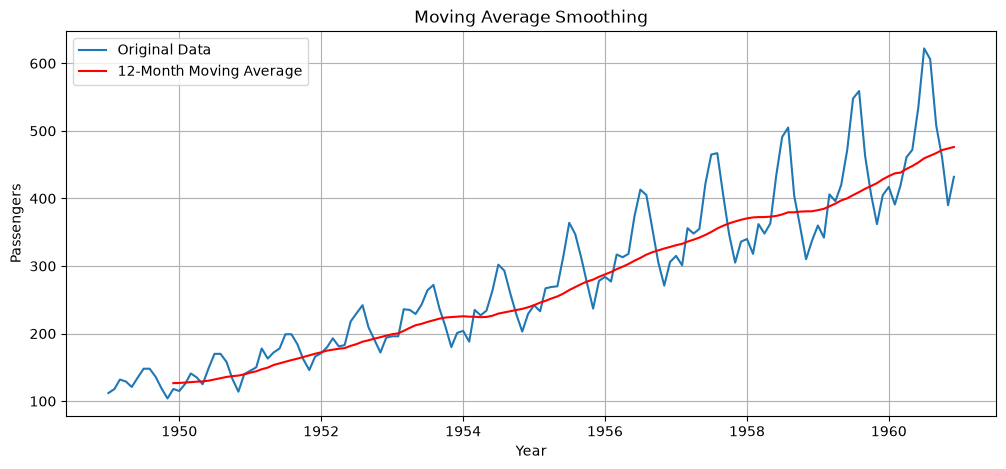

C:\Users\krish\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\krish\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\krish\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


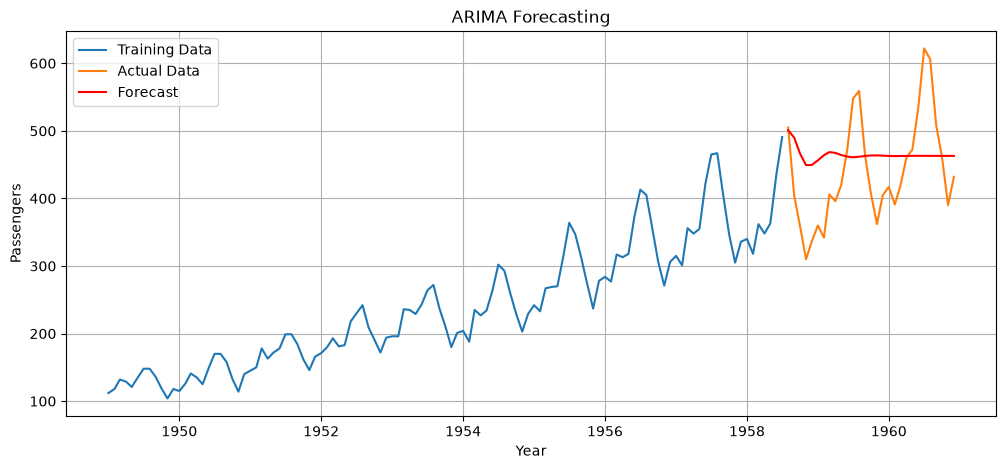


Forecast vs Actual:
            Actual    Forecast
Month                         
1958-08-01     505  500.902643
1958-09-01     404  489.904481
1958-10-01     359  466.349010
1958-11-01     310  449.296639
1958-12-01     337  449.565682
1959-01-01     360  456.411345
1959-02-01     342  463.997445
1959-03-01     406  468.568886
1959-04-01     396  467.408711
1959-05-01     420  464.273767


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# -------------------------------
# Load the Dataset
# -------------------------------

air_data = pd.read_csv("AirPassengers.csv")

# Convert Month column to datetime
air_data["Month"] = pd.to_datetime(air_data["Month"])

# Set Month as index
air_data.set_index("Month", inplace=True)

# Display first few rows
print("First 5 Rows:")
print(air_data.head())

# -------------------------------
# Plot Time Series
# -------------------------------

plt.figure(figsize=(12,5))
plt.plot(air_data["Passengers"], color="blue")
plt.title("Air Passengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()

# -------------------------------
# Seasonal Decomposition
# -------------------------------

decomposition = seasonal_decompose(
    air_data["Passengers"],
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

# -------------------------------
# Moving Average Smoothing
# -------------------------------

air_data["Moving_Average"] = air_data["Passengers"].rolling(window=12).mean()

plt.figure(figsize=(12,5))
plt.plot(air_data["Passengers"], label="Original Data")
plt.plot(air_data["Moving_Average"], color="red", label="12-Month Moving Average")
plt.title("Moving Average Smoothing")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Split Dataset
# -------------------------------

train_size = int(len(air_data) * 0.8)

train = air_data["Passengers"][:train_size]
test = air_data["Passengers"][train_size:]

# -------------------------------
# Build ARIMA Model
# -------------------------------

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

# -------------------------------
# Forecast
# -------------------------------

forecast = model_fit.forecast(steps=len(test))

# -------------------------------
# Plot Forecast
# -------------------------------

plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Data")
plt.plot(test.index, forecast, color="red", label="Forecast")

plt.title("ARIMA Forecasting")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Display Forecast Values
# -------------------------------

forecast_df = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast.values
}, index=test.index)

print("\nForecast vs Actual:")
print(forecast_df.head(10))